In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv')
print("Shape:", df.shape)
print(df.head())

Shape: (614, 13)
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2  

In [2]:
# Understanding our data
# Like checking array size in Java
print("Missing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

Missing Values:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Data Types:
 Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object


In [3]:
print("Missing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)


Missing Values:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Data Types:
 Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object


In [4]:
# Fill missing values
# mode() = most frequent value, like finding most common element in array
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


/tmp/ipykernel_2070/4041461964.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_2070/4041461964.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [5]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Convert text to numbers
# ML models only understand numbers, not text
cols = ['Gender','Married','Dependents','Education',
        'Self_Employed','Property_Area','Loan_Status']

for col in cols:
    df[col] = le.fit_transform(df[col])

print(df.head())

    Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
0  LP001002       1        0           0          0              0   
1  LP001003       1        1           1          0              0   
2  LP001005       1        1           0          0              1   
3  LP001006       1        1           0          1              0   
4  LP001008       1        0           0          0              0   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0       128.0             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History  Property_Area  Loan_Status  
0             1.0              2            1  
1             1.0              0            0  
2       

/tmp/ipykernel_2070/2373656929.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Loan_Status', data=df,


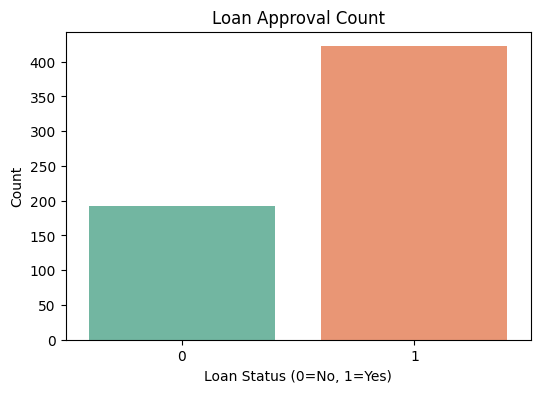

In [6]:
# EDA - Exploratory Data Analysis
# Visualization 1: Loan Approval Count
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df,
              palette='Set2')
plt.title('Loan Approval Count')
plt.xlabel('Loan Status (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

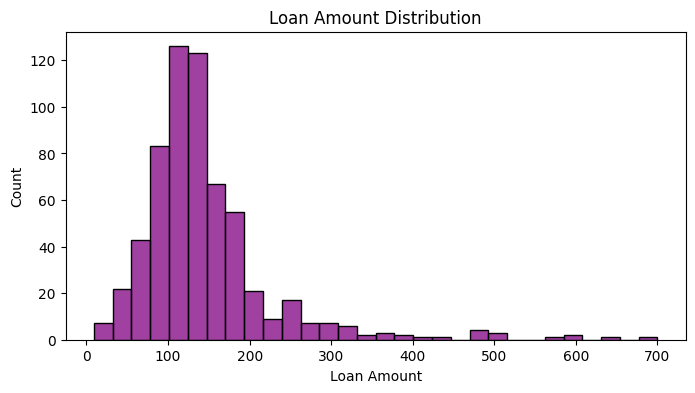

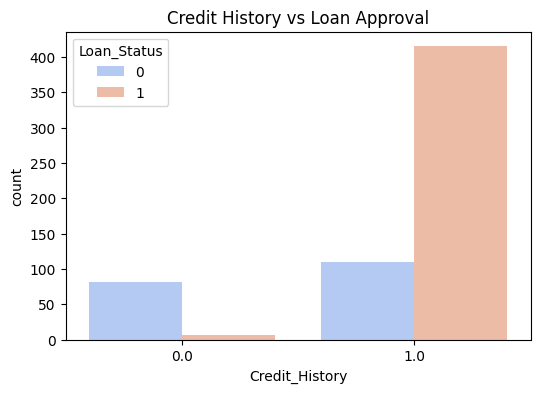

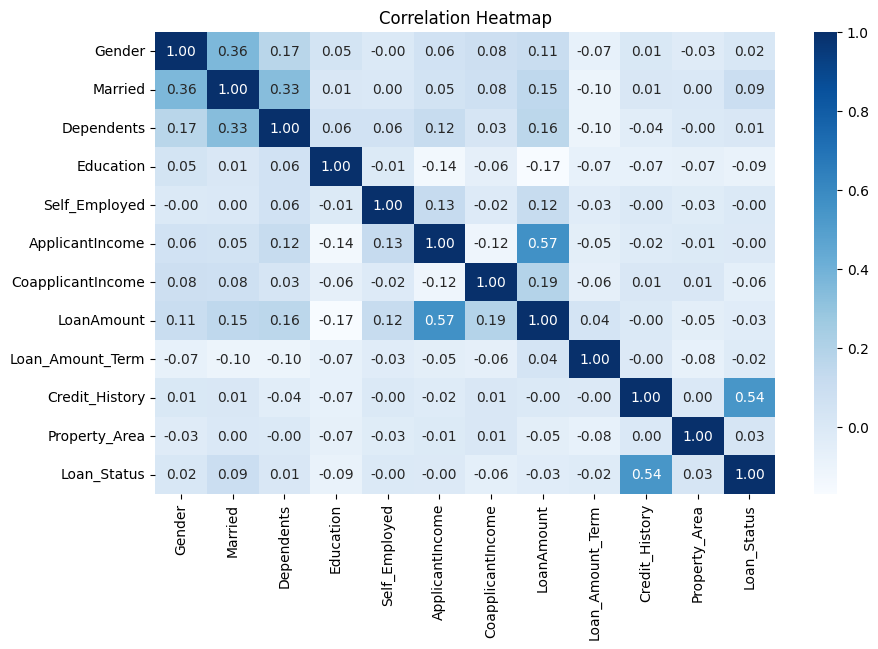

In [9]:
# Chart 2: Loan Amount Distribution
plt.figure(figsize=(8,4))
sns.histplot(df['LoanAmount'], bins=30, color='purple')
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.show()

# Chart 3: Credit History vs Loan Status
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_History', hue='Loan_Status',
              data=df, palette='coolwarm')
plt.title('Credit History vs Loan Approval')
plt.show()

# Chart 4: Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.drop('Loan_ID',axis=1).corr(), annot=True, fmt='.2f',
            cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

In [11]:
# Prepare data for ML
# X = input features, y = target (what we predict)
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Split: 80% training, 20% testing
# Like 80% practice, 20% exam
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (491, 12)
Testing size: (123, 12)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Model 1: Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Logistic Regression:", accuracy_score(y_test, lr_pred))

# Model 2: Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest:", accuracy_score(y_test, rf_pred))

# Model 3: XGBoost
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print("XGBoost:", accuracy_score(y_test, xgb_pred))

ValueError: could not convert string to float: 'LP001273'

In [13]:
# Fix: Drop Loan_ID from X properly
X = df.drop(['Loan_Status', 'Loan_ID'], axis=1, errors='ignore')
y = df['Loan_Status']

# Split again
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Logistic Regression:", accuracy_score(y_test, lr_pred))

# Model 2: Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest:", accuracy_score(y_test, rf_pred))

# Model 3: XGBoost
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print("XGBoost:", accuracy_score(y_test, xgb_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: 0.7886178861788617
Random Forest: 0.7560975609756098
XGBoost: 0.7398373983739838


In [14]:
import pickle

# Save best model (Logistic Regression)
with open('loan_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

print("Model saved!")

Model saved!


In [15]:
from sklearn.metrics import classification_report

print("=== Best Model: Logistic Regression ===")
print(classification_report(y_test, lr_pred))

=== Best Model: Logistic Regression ===
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123

